# Figure 2: held-out-serum split panels

Interactive companion to `plot_fig2_heldout_serum_splits.py`. Run cells from top to bottom. It reads the 10 real matched serum splits, recomputes identity-free metrics, displays the audit, and exports three Illustrator-ready panels.

The output figures deliberately contain no A/B/C labels or manuscript headers; those can be composed in Illustrator.


In [1]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import SVG, display

REPO_ROOT = Path('/home/chenyh/workspace/fluProfiler')
SCRIPT_PATH = REPO_ROOT / 'paper/Code/plot_fig2_heldout_serum_splits.py'
RESULTS_ROOT = REPO_ROOT / 'results/H3_HA1_v1.0/20260827_112805'
OUTPUT_DIR = REPO_ROOT / 'paper/Code/Fig2_heldout_serum_panels'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

spec = importlib.util.spec_from_file_location('fig2_heldout', SCRIPT_PATH)
fig2 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fig2)

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
FONT_FAMILY = next((name for name in ('Arial', 'Liberation Sans', 'DejaVu Sans') if name in available_fonts), 'sans-serif')
plt.rcParams.update({
    'font.family': FONT_FAMILY, 'font.size': 9, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'axes.linewidth': 1.0,
    'svg.fonttype': 'none', 'pdf.fonttype': 42, 'savefig.transparent': True,
})
print(f'Using font: {FONT_FAMILY}')


Using font: Liberation Sans


## Load and audit the 10 matched splits

This verifies that the three models use the same sequence-pair multiset in every split.


In [2]:
metrics, audit = fig2.collect_metrics(RESULTS_ROOT)
metrics.to_csv(OUTPUT_DIR / 'heldout_serum_results.csv', index=False)
audit.to_csv(OUTPUT_DIR / 'heldout_serum_input_audit.csv', index=False)

display(metrics)
display(audit)
display(metrics.groupby('model')[['MAE', 'Pearson', 'Spearman']].agg(['mean', 'std']))


,split,model,MAE,Pearson,Spearman,n_test_pairs
0,0,AdaBoost,1.097961,0.566708,0.553095,10817
1,0,Nextflu,1.289867,0.637588,0.578749,10817
2,0,fluProfiler,1.189626,0.549041,0.489122,10817
3,1,AdaBoost,1.043372,0.662634,0.704565,6717
4,1,Nextflu,1.690670,0.502692,0.579932,6717
5,1,fluProfiler,0.970220,0.733910,0.764039,6717
6,2,AdaBoost,1.126103,0.478008,0.436774,2764
7,2,Nextflu,0.906605,0.665065,0.617331,2764
8,2,fluProfiler,0.943470,0.663171,0.622336,2764
9,3,AdaBoost,1.263278,0.286287,0.304238,5805


,split,model,n_test_pairs,sequence_pair_multiset_matches_fluProfiler,labelled_pair_multiset_matches_fluProfiler
0,0,AdaBoost,10817,True,False
1,0,Nextflu,10817,True,False
2,0,fluProfiler,10817,True,True
3,1,AdaBoost,6717,True,False
4,1,Nextflu,6717,True,False
5,1,fluProfiler,6717,True,True
6,2,AdaBoost,2764,True,False
7,2,Nextflu,2764,True,False
8,2,fluProfiler,2764,True,True
9,3,AdaBoost,5805,True,False


MAE             Pearson            Spearman          
                 mean       std      mean       std      mean       std
model                                                                  
AdaBoost     1.084887  0.111426  0.547073  0.141600  0.534806  0.138487
Nextflu      1.227085  0.251664  0.586568  0.099938  0.580575  0.109312
fluProfiler  1.031800  0.122157  0.651030  0.072591  0.632298  0.085310

## Optional visual settings

Edit colors or output directory here, then rerun the export cell.


In [3]:
fig2.COLORS.update({'fluProfiler': '#0012E6', 'AdaBoost': '#003642', 'Nextflu': '#8D5103'})
TOP_N_SPLITS = 10
assert metrics['split'].nunique() == TOP_N_SPLITS


## Export independent panels

Each panel contains a light boxplot, all ten split points, and mean ± sample SD. SVG text remains editable for Illustrator.


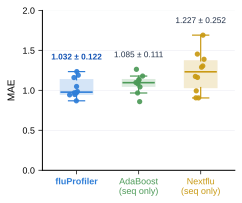

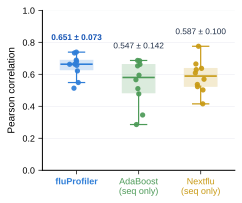

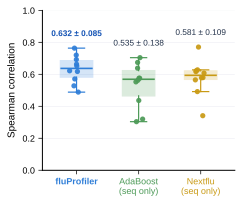

Exported SVG, PDF and 600-dpi PNG files to: /home/chenyh/workspace/fluProfiler/paper/Code/Fig2_heldout_serum_panels


In [4]:
fig2.draw_metric_panel(metrics, 'MAE', 'MAE', 'Fig2A_HeldoutSerum_MAE', OUTPUT_DIR)
fig2.draw_metric_panel(metrics, 'Pearson', 'Pearson correlation', 'Fig2B_HeldoutSerum_Pearson', OUTPUT_DIR)
fig2.draw_metric_panel(metrics, 'Spearman', 'Spearman correlation', 'Fig2C_HeldoutSerum_Spearman', OUTPUT_DIR)

for stem in ('Fig2A_HeldoutSerum_MAE', 'Fig2B_HeldoutSerum_Pearson', 'Fig2C_HeldoutSerum_Spearman'):
    display(SVG(filename=OUTPUT_DIR / f'{stem}.svg'))
print(f'Exported SVG, PDF and 600-dpi PNG files to: {OUTPUT_DIR}')


## Supplementary analysis: held-out antiserum conditions with identity-aware baselines

This sensitivity analysis retains the identity-free fluProfiler predictions but evaluates AdaBoost and Nextflu using their saved identity-aware (`with-name`) predictions. It uses the same ten held-out antiserum-condition splits and validates that every model is evaluated on exactly the same test-pair multiset. The audit also records label agreement; small cross-file differences can arise from stored floating-point precision. The results are intended as Supplementary Figure panels, not as a replacement for the identity-masked primary comparison.

In [ ]:
import pandas as pd

WITH_NAME_OUTPUT_DIR = REPO_ROOT / 'paper/Code/FigS_heldout_serum_identity_aware'


def with_name_prediction_path(results_root, model, split):
    if model == 'fluProfiler':
        return results_root / f'SCMS-FiLM-H3/serum/seed_{split}/subtype/H3N2_seed42/predictions_test.csv', 'mean'
    if model == 'AdaBoost':
        return results_root / f'Adaboost/serum/seed_{split}/H3N2/predictions.csv', 'prediction'
    if model == 'Nextflu':
        return results_root / f'Nextflu/serum/seed_{split}/H3N2/predictions.csv', 'pred_with_name'
    raise ValueError(f'Unsupported model: {model}')


def read_with_name_test_predictions(path, model, prediction_column):
    columns = [*fig2.PAIR_KEY_COLUMNS, 'label', prediction_column]
    frame = pd.read_csv(path, usecols=lambda name: name in set(columns) | {'split'})
    if 'split' in frame.columns:
        frame = frame.loc[frame['split'].eq('test')].copy().drop(columns='split')
    if frame.empty:
        raise ValueError(f'{path}: no test predictions found')
    if frame[prediction_column].isna().any() or frame['label'].isna().any():
        raise ValueError(f'{path}: missing prediction or label values')
    return frame.rename(columns={prediction_column: 'prediction'})


def collect_identity_aware_heldout_metrics(results_root):
    rows, audit_rows = [], []
    for split in range(10):
        frames = {}
        source_columns = {}
        for model in fig2.MODEL_ORDER:
            path, prediction_column = with_name_prediction_path(results_root, model, split)
            if not path.is_file():
                raise FileNotFoundError(path)
            frames[model] = read_with_name_test_predictions(path, model, prediction_column)
            source_columns[model] = prediction_column

        reference_pair_signature = fig2.pair_signature(frames['fluProfiler'])
        reference_labelled_signature = fig2.pair_signature(
            frames['fluProfiler'], fig2.LABELLED_PAIR_KEY_COLUMNS
        )
        for model, frame in frames.items():
            pair_match = (fig2.pair_signature(frame) == reference_pair_signature).all()
            labelled_pair_match = (
                fig2.pair_signature(frame, fig2.LABELLED_PAIR_KEY_COLUMNS)
                == reference_labelled_signature
            ).all()
            if not pair_match:
                raise ValueError(f'split {split}: {model} test pairs do not match fluProfiler')
            rows.append({
                'split': split,
                'model': model,
                'identity_setting': 'identity-free' if model == 'fluProfiler' else 'identity-aware',
                'prediction_column': source_columns[model],
                **fig2.compute_metrics(frame),
            })
            audit_rows.append({
                'split': split,
                'model': model,
                'prediction_column': source_columns[model],
                'n_test_pairs': len(frame),
                'sequence_pair_multiset_matches_fluProfiler': pair_match,
                'labelled_pair_multiset_matches_fluProfiler': labelled_pair_match,
            })
    return pd.DataFrame(rows).sort_values(['split', 'model']).reset_index(drop=True), pd.DataFrame(audit_rows).sort_values(['split', 'model']).reset_index(drop=True)


heldout_metrics_with_name, heldout_audit_with_name = collect_identity_aware_heldout_metrics(RESULTS_ROOT)
assert len(heldout_metrics_with_name) == 30
assert heldout_audit_with_name['sequence_pair_multiset_matches_fluProfiler'].all()

display(heldout_metrics_with_name)
display(heldout_audit_with_name)
with_name_metric_summary = (
    heldout_metrics_with_name.groupby(['model', 'identity_setting'])[['MAE', 'Pearson', 'Spearman']]
    .agg(['mean', 'std'])
)
display(with_name_metric_summary)

### Export Supplementary Figure panels and source tables

The exported panels label AdaBoost and Nextflu as `with name`. `FigS` remains a placeholder until the final Supplementary Figure order is assigned.

In [ ]:
WITH_NAME_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
heldout_metrics_with_name.to_csv(
    WITH_NAME_OUTPUT_DIR / 'FigS_heldout_serum_results_identity_aware.csv', index=False
)
heldout_audit_with_name.to_csv(
    WITH_NAME_OUTPUT_DIR / 'FigS_heldout_serum_input_audit_identity_aware.csv', index=False
)
with_name_metric_summary.to_csv(
    WITH_NAME_OUTPUT_DIR / 'FigS_heldout_serum_summary_identity_aware.csv'
)

original_labels = fig2.MODEL_LABELS.copy()
fig2.MODEL_LABELS.update({
    'AdaBoost': 'AdaBoost\n(with name)',
    'Nextflu': 'Nextflu\n(with name)',
})
try:
    panel_specs = (
        ('MAE', 'MAE', 'FigS_HeldoutSerum_MAE_IdentityAwareBaselines'),
        ('Pearson', 'Pearson correlation', 'FigS_HeldoutSerum_Pearson_IdentityAwareBaselines'),
        ('Spearman', 'Spearman correlation', 'FigS_HeldoutSerum_Spearman_IdentityAwareBaselines'),
    )
    for metric, ylabel, stem in panel_specs:
        fig2.draw_metric_panel(heldout_metrics_with_name, metric, ylabel, stem, WITH_NAME_OUTPUT_DIR)
finally:
    fig2.MODEL_LABELS.clear()
    fig2.MODEL_LABELS.update(original_labels)

for _, _, stem in panel_specs:
    display(SVG(filename=WITH_NAME_OUTPUT_DIR / f'{stem}.svg'))
print(f'Wrote 30-row metrics table and audit to: {WITH_NAME_OUTPUT_DIR}')
print('Wrote SVG, PDF and 600-dpi PNG Supplementary panels.')